# GATv2 — Fixed Architecture, Batch of Feature Configurations (HI-Small)

- **Question:** what do engineered edge features add when the GNN architecture is held *exactly* fixed?
- **Knobs per config:** `mp` = edge features in message passing (`none` / `base` / `full`), `readout` = edge features at the classifier (`base` / `full` / `gfp`). Direction and temporal sampling are fixed per batch.
- **Everything shared** (model template, training loop, threshold selection, metrics, plots, saving) lives in `gnn_core.py`. This notebook only sets `OPERATOR`, the config batch and paths.
- **Protocol:** threshold swept on validation each epoch, best-val-F1 checkpoint, test scored once; every metric on train / val / test. `invariant_params` must be **67,585** in every run.

## 0. Environment (Kaggle)

- Pinned PyTorch / PyG stack known to work on Kaggle GPU — do not change versions or order.
- Then clone (or pull) the public repo so the committed `gnn_core.py` is the one imported.

In [1]:
!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse pyg_lib
!pip install torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch_geometric

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 145.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 225.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 158.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 72.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 97.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 126.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import sys

REPO_URL = 'https://github.com/sandrokhizanishvili/gnn_for_fraudulent_patterns.git'
REPO_DIR = '/kaggle/working/gnn_for_fraudulent_patterns'
if os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull
else:
    !git clone {REPO_URL} {REPO_DIR}
!git -C {REPO_DIR} log -1 --oneline
sys.path.append(REPO_DIR)

Cloning into '/kaggle/working/gnn_for_fraudulent_patterns'...
remote: Enumerating objects: 109, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 109 (delta 37), reused 93 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (109/109), 3.51 MiB | 14.51 MiB/s, done.
Resolving deltas: 100% (37/37), done.
88a52ea (HEAD -> main, origin/main, origin/HEAD) Outputs/GIN: results.json, history.csv, curves.png and batch_summary.csv of the seven GIN runs (26 Sep batch, full evaluation protocol)


## 1. Configuration

- The only cell that differs between operator notebooks (`GIN_` / `PNA_` / `GAT_`).
- `CONFIGS`: one dict per run of this batch; run numbers refer to `EXPERIMENTS.md`.
- `OUT_ROOT` mirrors `Outputs/GAT/` in the repo; the zip in section 6 is what gets committed (minus `best.pt`).

In [3]:
OPERATOR = 'gat'

# knob configs of this batch — one dict per run
CONFIGS = [
    dict(mp='none', readout='base'),   # GAT-1 — topology alone, the reference point
    dict(mp='base', readout='base'),   # GAT-2 — edge features inside message passing
    dict(mp='none', readout='full'),   # GAT-3 — GFP only at the decision layer
    dict(mp='full', readout='full'),   # GAT-4 — GFP everywhere
    dict(mp='base', readout='full'),   # GAT-5 — GFP at the decision layer only
    dict(mp='base', readout='gfp'),    # GAT-6 — are raw features redundant once message passing has used them?
    dict(mp='none', readout='gfp'),    # GAT-7 — GFP alone vs baseline alone (compare with GAT-1)
]
MP_DIRECTION      = 'in'     # 'in' | 'bidirectional' — fixed for the whole batch
TEMPORAL_SAMPLING = False    # True samples only edges earlier than the seed (needs pyg-lib)

# paths
DATA_DIR    = '/kaggle/input/datasets/sandrokhizanishvili/hi-small-gnn'
OUT_ROOT    = '/kaggle/working/Outputs/GAT'      # mirrors Outputs/GAT/ in the repo

import gnn_core as core
# core.ACCUM_STEPS = 2   # only if the first Kaggle attempt runs out of GPU memory: same 8,192-seed update in 2 micro-batches; recorded in results.json
os.makedirs(OUT_ROOT, exist_ok=True)
print(f'torch {core.torch.__version__} | device {core.device} | gnn_core from {core.__file__}')

torch 2.8.0+cu126 | device cuda | gnn_core from /kaggle/working/gnn_for_fraudulent_patterns/gnn_core.py


## 2. Load graphs

- Three cumulative PyG snapshots; context edges carry label −1, only `eval_mask` edges are scored.
- `col_sets` maps each knob value to `edge_attr` columns: base = first 20, gfp = next 61, full = all 81.

In [4]:
graphs, col_sets, node_dim = core.load_graphs(DATA_DIR)

train nodes=515,070 edges=3,046,342 evaluated=3,046,342 laundering=2,297 (0.0754%)
val   nodes=515,070 edges=4,061,789 evaluated=1,015,447 laundering=1,082 (0.1066%)
test  nodes=515,070 edges=5,077,237 evaluated=1,015,448 laundering=1,143 (0.1126%)


## 3. Model

- Fixed template (`gnn_core.EdgeClassifier`): `node_proj` → 2 message-passing layers (hidden 128, dropout 0.3, residual) → readout MLP on `[h_src ‖ h_dst ‖ e_seed]`.
- `GATv2Conv`, 4 heads × 32 concatenated = 128; `mp ≠ none` adds only the edge projection `lin_edge(edge_dim)`.
- Between configs only `lin_edge` and the readout's first `Linear` change width; `invariant_params` counts the rest and must be 67,585.

In [5]:
cfg = CONFIGS[0]
model = core.build_model(OPERATOR, node_dim, len(col_sets[cfg['mp']]), len(col_sets[cfg['readout']]),
                         MP_DIRECTION == 'bidirectional')
print(model)
print(f'params {core.count_params(model):,} | invariant_params {core.invariant_params(model):,}   (config {cfg})')
del model

EdgeClassifier(
  (node_proj): Linear(in_features=6, out_features=128, bias=True)
  (layers): ModuleList(
    (0-1): 2 x MPLayer(
      (conv_in): GATv2Conv(128, 32, heads=4)
      (dropout): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=276, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
params 103,041 | invariant_params 67,585   (config {'mp': 'none', 'readout': 'base'})


## 4. Run the batch

- One call per config: seed → model → loaders → 20 epochs → best checkpoint → all splits scored → `results.json`, `history.csv`, `curves.png`, `best.pt`, `predictions.csv` under `OUT_ROOT/<run>/`.
- `predictions.csv`: every evaluated edge of train / val / test with `edge_id` (= row in `Data/edge_features.csv`), `src`, `dst`, `edge_time`, `y`, `prob` (probability) and `pred` (class at the val-chosen threshold) — for the typology / error analyses.
- Per-epoch line: train / val loss, F1 (train at the val threshold), PR-AUC, seconds, RAM; `* new best` marks a checkpoint.

=== gat_mp-none_readout-base_dir-in ===
MP edge features: 0 | readout edge features: 20
total params: 103,041 | architecture-invariant: 67,585


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0173 / 0.0230 | F1 0.3407 / 0.4355 @ 0.355 | PR-AUC 0.3028 / 0.3544 | 69s | RAM 6.7GB   (train / val)   * new best -> best.pt
best validation F1 0.4355 at epoch 20 (threshold 0.355)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.3409  0.4343  0.3916
precision          0.3531  0.6036  0.5127
recall             0.3296  0.3392  0.3167
pr_auc             0.3028  0.3543  0.3303
roc_auc            0.9742  0.9736  0.9726
precision_at_5pct  0.0123  0.0180  0.0189
recall_at_5pct     0.8180  0.8447  0.8408
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GAT/gat_mp-none_readout-base_dir-in/predictions.csv


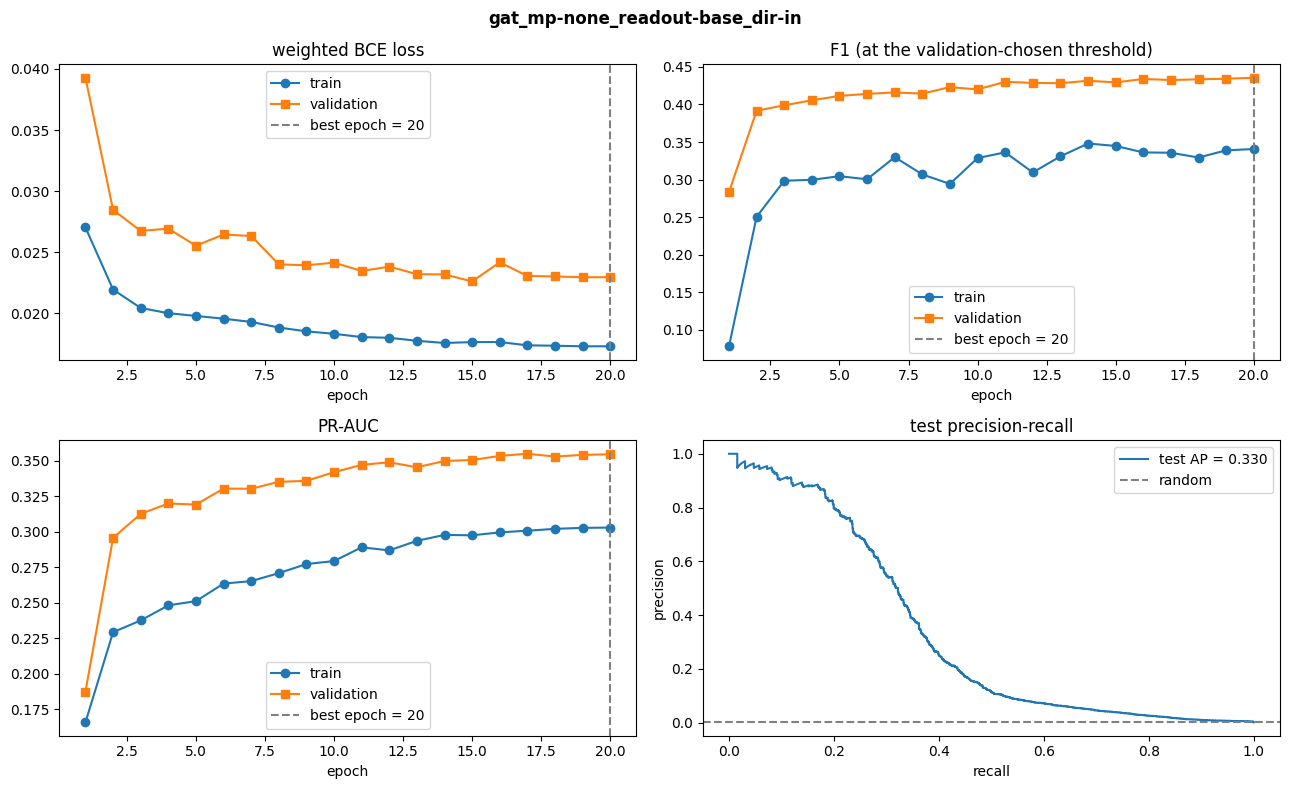

=== gat_mp-base_readout-base_dir-in ===
MP edge features: 20 | readout edge features: 20
total params: 108,161 | architecture-invariant: 67,585


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0154 / 0.0203 | F1 0.4053 / 0.4932 @ 0.443 | PR-AUC 0.3771 / 0.4424 | 88s | RAM 7.7GB   (train / val)
best validation F1 0.4976 at epoch 13 (threshold 0.477)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.3882  0.4979  0.4351
precision          0.4267  0.7257  0.5898
recall             0.3561  0.3789  0.3447
pr_auc             0.3610  0.4394  0.3886
roc_auc            0.9784  0.9779  0.9750
precision_at_5pct  0.0127  0.0183  0.0189
recall_at_5pct     0.8424  0.8567  0.8408
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GAT/gat_mp-base_readout-base_dir-in/predictions.csv


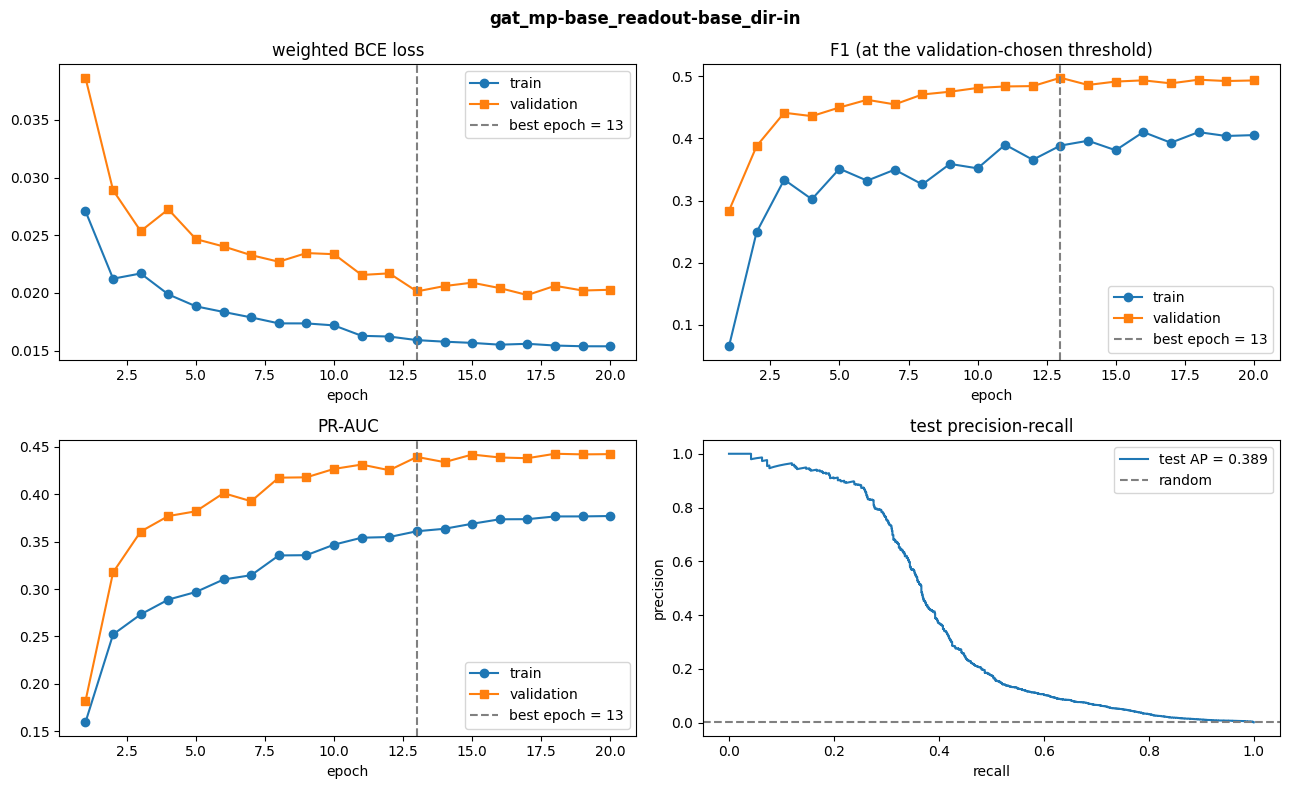

=== gat_mp-none_readout-full_dir-in ===
MP edge features: 0 | readout edge features: 81
total params: 110,849 | architecture-invariant: 67,585


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0148 / 0.0195 | F1 0.4520 / 0.5243 @ 0.480 | PR-AUC 0.3939 / 0.4542 | 69s | RAM 8.0GB   (train / val)   * new best -> best.pt
best validation F1 0.5243 at epoch 20 (threshold 0.480)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.4518  0.5243  0.4689
precision          0.5552  0.6887  0.6151
recall             0.3809  0.4233  0.3788
pr_auc             0.3940  0.4542  0.4191
roc_auc            0.9832  0.9799  0.9786
precision_at_5pct  0.0131  0.0182  0.0192
recall_at_5pct     0.8707  0.8549  0.8530
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GAT/gat_mp-none_readout-full_dir-in/predictions.csv


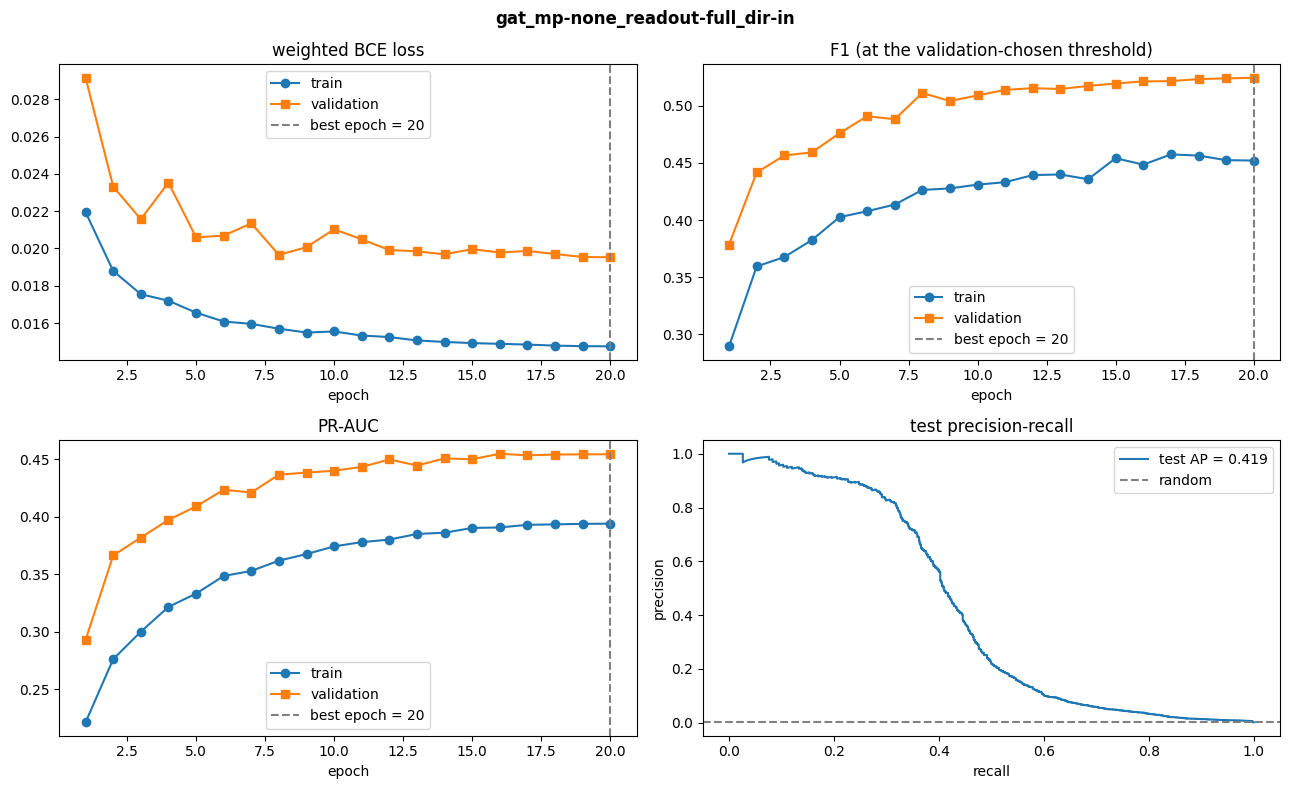

=== gat_mp-full_readout-full_dir-in ===
MP edge features: 81 | readout edge features: 81
total params: 131,585 | architecture-invariant: 67,585


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0130 / 0.0188 | F1 0.5089 / 0.5694 @ 0.526 | PR-AUC 0.4776 / 0.5120 | 150s | RAM 11.8GB   (train / val)
best validation F1 0.5704 at epoch 19 (threshold 0.513)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5071  0.5696  0.4879
precision          0.5966  0.7648  0.6113
recall             0.4410  0.4538  0.4059
pr_auc             0.4774  0.5117  0.4581
roc_auc            0.9876  0.9805  0.9781
precision_at_5pct  0.0137  0.0182  0.0189
recall_at_5pct     0.9064  0.8558  0.8408
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GAT/gat_mp-full_readout-full_dir-in/predictions.csv


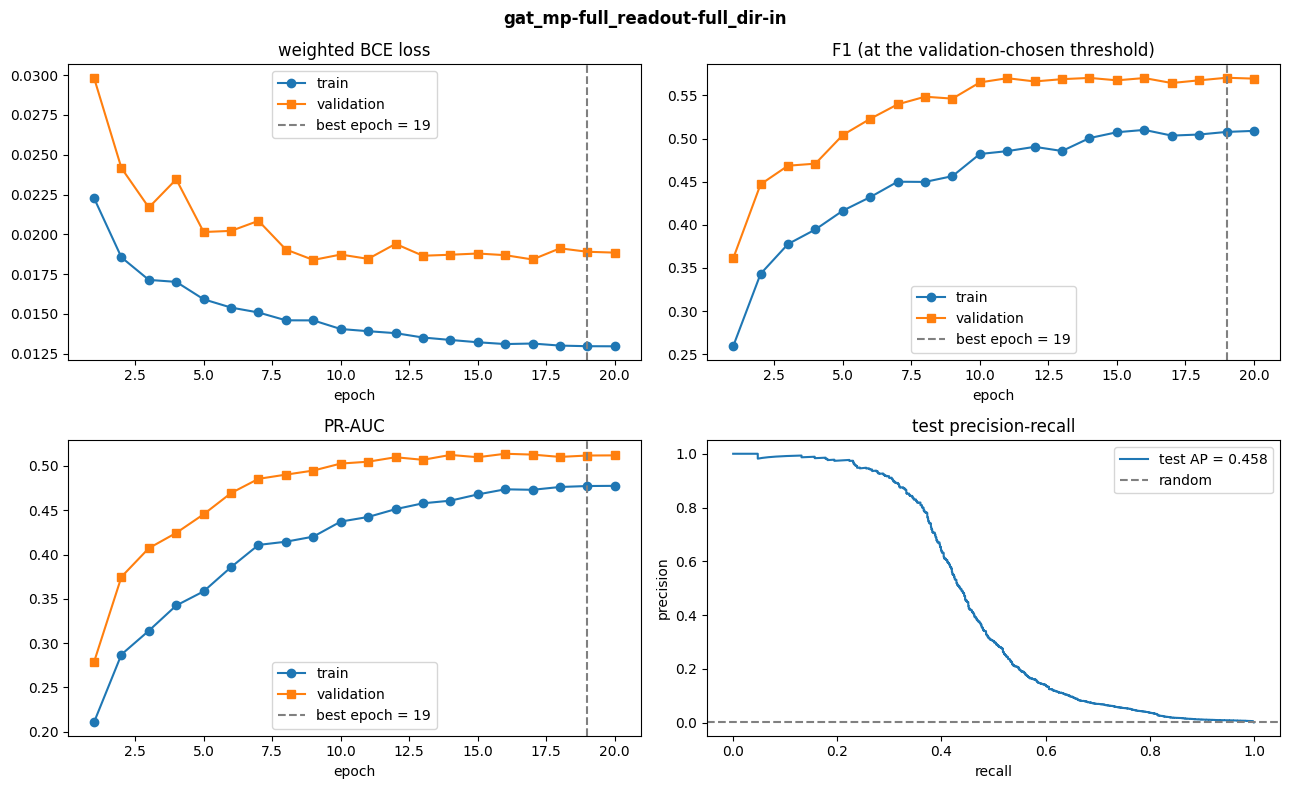

=== gat_mp-base_readout-full_dir-in ===
MP edge features: 20 | readout edge features: 81
total params: 115,969 | architecture-invariant: 67,585


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0141 / 0.0185 | F1 0.4752 / 0.5501 @ 0.603 | PR-AUC 0.4239 / 0.4979 | 88s | RAM 8.9GB   (train / val)   * new best -> best.pt
best validation F1 0.5501 at epoch 20 (threshold 0.603)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.4751  0.5505  0.5003
precision          0.6794  0.8137  0.7204
recall             0.3653  0.4159  0.3832
pr_auc             0.4240  0.4979  0.4506
roc_auc            0.9848  0.9817  0.9795
precision_at_5pct  0.0132  0.0185  0.0192
recall_at_5pct     0.8777  0.8660  0.8513
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GAT/gat_mp-base_readout-full_dir-in/predictions.csv


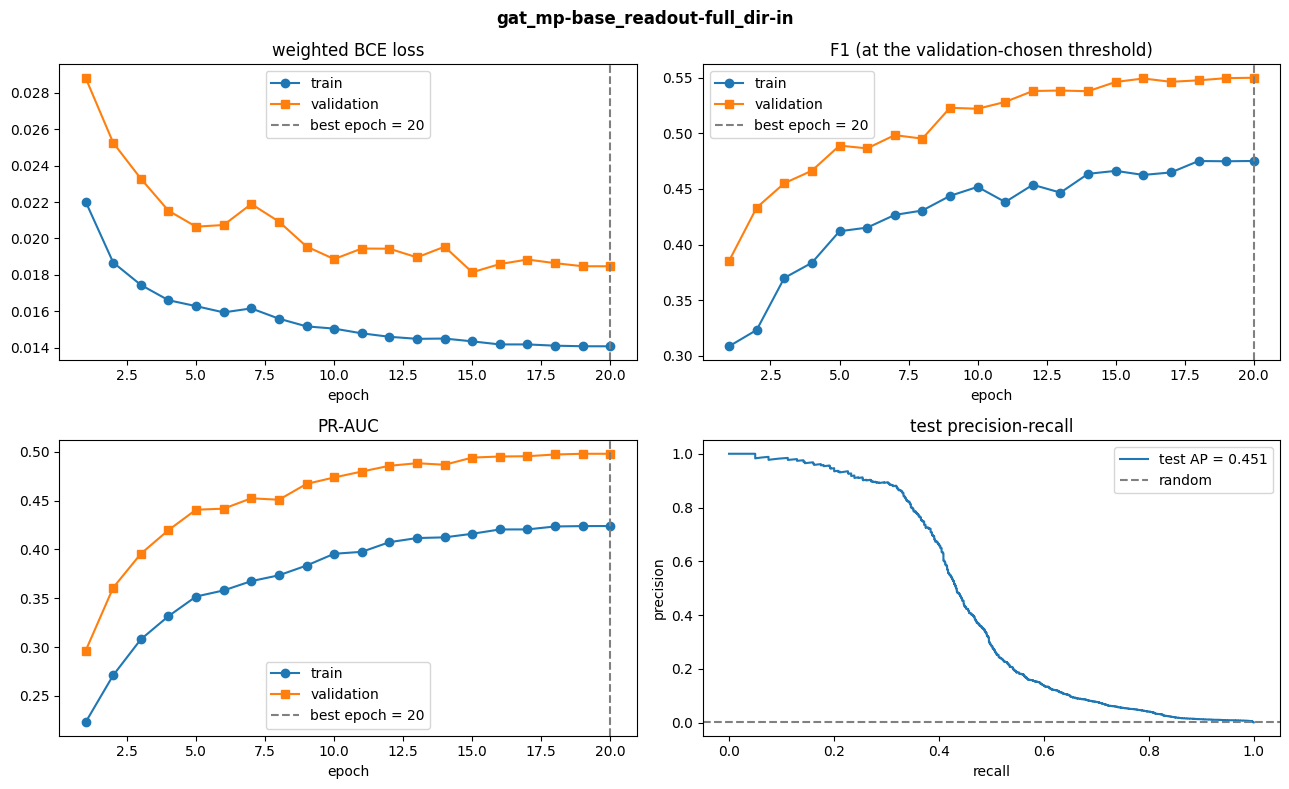

=== gat_mp-base_readout-gfp_dir-in ===
MP edge features: 20 | readout edge features: 61
total params: 113,409 | architecture-invariant: 67,585


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0166 / 0.0223 | F1 0.3836 / 0.4389 @ 0.651 | PR-AUC 0.3133 / 0.3369 | 87s | RAM 8.6GB   (train / val)
best validation F1 0.4412 at epoch 17 (threshold 0.698)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.3795  0.4412  0.3787
precision          0.6028  0.5554  0.4113
recall             0.2769  0.3660  0.3508
pr_auc             0.3114  0.3362  0.3117
roc_auc            0.9748  0.9654  0.9597
precision_at_5pct  0.0125  0.0169  0.0177
recall_at_5pct     0.8276  0.7948  0.7865
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GAT/gat_mp-base_readout-gfp_dir-in/predictions.csv


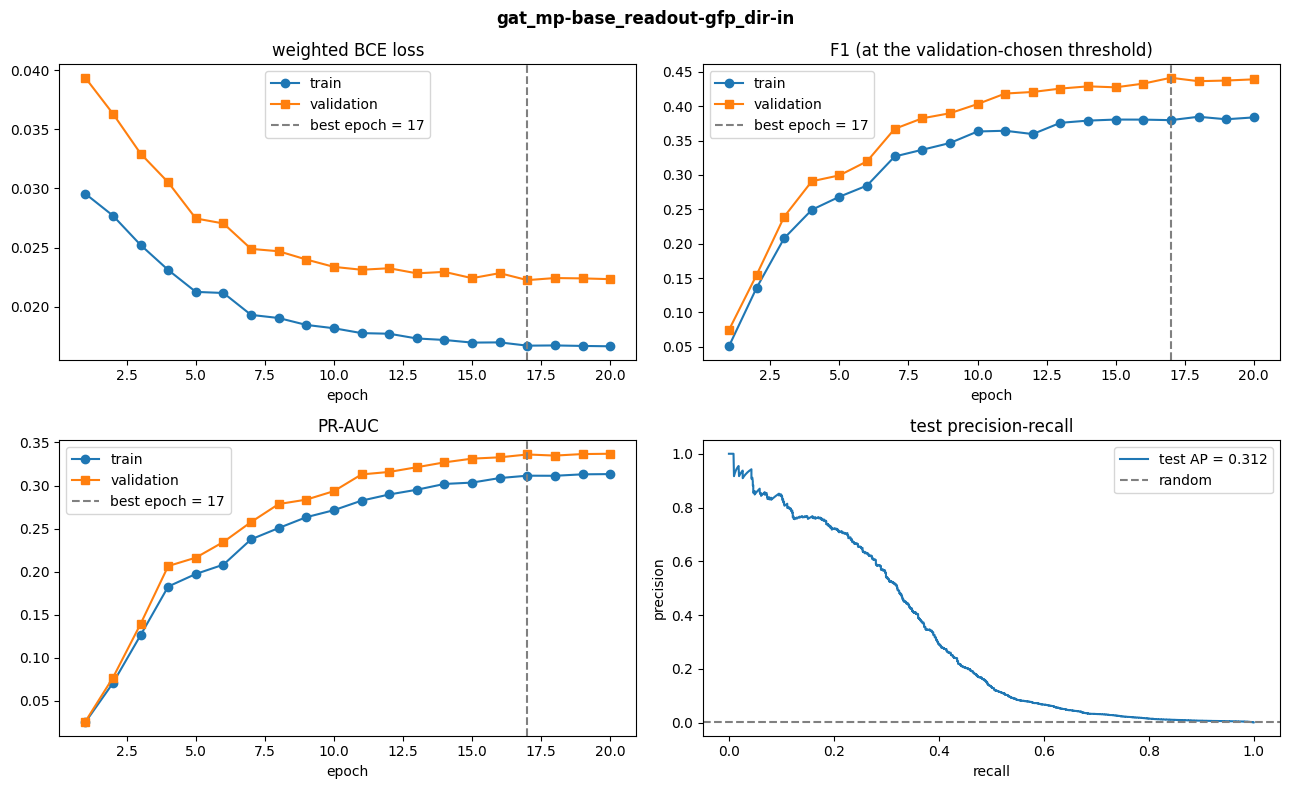

=== gat_mp-none_readout-gfp_dir-in ===
MP edge features: 0 | readout edge features: 61
total params: 108,289 | architecture-invariant: 67,585


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0232 / 0.0306 | F1 0.2175 / 0.2400 @ 0.385 | PR-AUC 0.1383 / 0.1599 | 68s | RAM 7.7GB   (train / val)   * new best -> best.pt
best validation F1 0.2400 at epoch 20 (threshold 0.385)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.2176  0.2400  0.1839
precision          0.3278  0.2683  0.1540
recall             0.1628  0.2172  0.2283
pr_auc             0.1383  0.1598  0.1122
roc_auc            0.9359  0.9287  0.9187
precision_at_5pct  0.0099  0.0143  0.0143
recall_at_5pct     0.6582  0.6728  0.6369
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GAT/gat_mp-none_readout-gfp_dir-in/predictions.csv


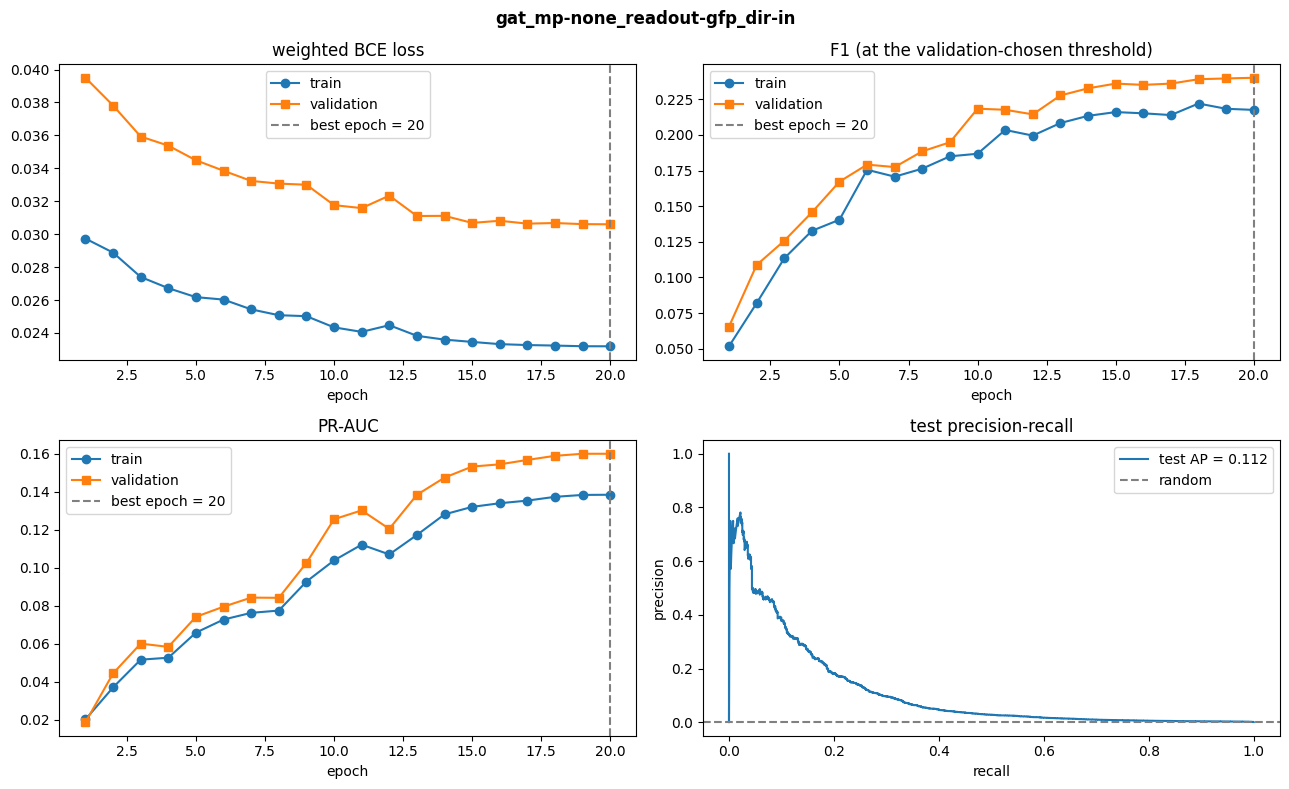

batch complete


In [6]:
rows = []
for cfg in CONFIGS:
    print('=' * 90)
    rows.append(core.run_experiment(OPERATOR, cfg, graphs, col_sets, node_dim, OUT_ROOT,
                                    MP_DIRECTION, TEMPORAL_SAMPLING))
print('=' * 90)
print('batch complete')

## 5. Comparison across the batch

- `batch_summary.csv` holds every `<split>_<metric>` column plus `threshold`, `best_epoch`, `params`, `invariant_params`.
- `invariant_params` must be identical in every row (asserted).

In [7]:
summary = core.summarize_batch(rows, OUT_ROOT)
summary[core.DISPLAY_COLS].round(4)

7 runs -> /kaggle/working/Outputs/GAT/batch_summary.csv | invariant_params = 67,585 in every row


,run,best_epoch,threshold,val_f1,test_f1,test_precision,test_recall,test_pr_auc,test_precision_at_5pct,test_recall_at_5pct,params,invariant_params
0,gat_mp-none_readout-base_dir-in,20,0.3554,0.4343,0.3916,0.5127,0.3167,0.3303,0.0189,0.8408,103041,67585
1,gat_mp-base_readout-base_dir-in,13,0.4771,0.4979,0.4351,0.5898,0.3447,0.3886,0.0189,0.8408,108161,67585
2,gat_mp-none_readout-full_dir-in,20,0.4796,0.5243,0.4689,0.6151,0.3788,0.4191,0.0192,0.8530,110849,67585
3,gat_mp-full_readout-full_dir-in,19,0.5127,0.5696,0.4879,0.6113,0.4059,0.4581,0.0189,0.8408,131585,67585
4,gat_mp-base_readout-full_dir-in,20,0.6034,0.5505,0.5003,0.7204,0.3832,0.4506,0.0192,0.8513,115969,67585
5,gat_mp-base_readout-gfp_dir-in,17,0.6977,0.4412,0.3787,0.4113,0.3508,0.3117,0.0177,0.7865,113409,67585
6,gat_mp-none_readout-gfp_dir-in,20,0.3855,0.2400,0.1839,0.1540,0.2283,0.1122,0.0143,0.6369,108289,67585


## 6. Download

- Zip `OUT_ROOT`; extract into `Outputs/GAT/` in the repo and commit the small result files (`best.pt` and `predictions.csv` stay out of git).

In [8]:
import shutil
shutil.make_archive(f'/kaggle/working/Outputs_{OPERATOR.upper()}', 'zip', OUT_ROOT)

'/kaggle/working/Outputs_GAT.zip'